In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
dataset_path = '/kaggle/input/datasets/azizrixsiev/uzbekistan-land-crop-dataset/CAWa_cropType/CAWa_CropType_samples.shp'

gdf = gpd.read_file(dataset_path)

print("Number of fields (polygons):", len(gdf))
print("Columns:", gdf.columns.tolist())

if 'crop_type' in gdf.columns:
    print("\nTop 10 crop types:")
    print(gdf['crop_type'].value_counts().head(10))
else:
    print("\nNo 'crop_type' column found. Available columns:", gdf.columns.tolist())
    print("\nFirst 5 rows:")
    print(gdf.head())

ts_path = '/kaggle/input/datasets/azizrixsiev/uzbekistan-land-crop-dataset/CAWa_cropType/CAWa_CropType_time-series.csv'
ts = pd.read_csv(ts_path)
print("\nTime-series shape:", ts.shape)
print("Time-series columns:", ts.columns.tolist())
print("\nFirst 5 rows of time-series:")
print(ts.head())

Number of fields (polygons): 8435
Columns: ['sampler', 'country', 'region', 'date', 'year', 'label_1', 'label_2', 'area', 'geometry']

No 'crop_type' column found. Available columns: ['sampler', 'country', 'region', 'date', 'year', 'label_1', 'label_2', 'area', 'geometry']

First 5 rows:
    sampler     country   region        date  year      label_1 label_2  \
0  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer   
1  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer   
2  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer   
3  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011  wheat-other  double   
4  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer   

            area                                           geometry  
0  159710.395957  POLYGON ((71.53066 40.49702, 71.53303 40.49595...  
1  193109.525223  POLYGON ((71.54027 40.49276, 71.5452 40.49053,...  
2   70290.481564  POLYGON ((71.54803 40.49244, 71.

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 100)

print("First 10 fields:")
print(gdf.head(10)[['sampler', 'country', 'region', 'date', 'year', 'label_1', 'label_2', 'area']])

First 10 fields:
    sampler     country   region        date  year      label_1 label_2           area
0  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer  159710.395957
1  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer  193109.525223
2  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer   70290.481564
3  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011  wheat-other  double   86003.121742
4  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer  168024.789200
5  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011  wheat-other  double   68483.672733
6  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011       cotton  summer  119170.926657
7  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011  wheat-other  double  168992.536423
8  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011        wheat  winter   97269.846085
9  SIC-ICWC  Uzbekistan  Fergana  2011-06-14  2011  wheat-other  double   98435.311300


In [5]:
# load the data and preprocess it (clean very rare columns, less than 30)
shp_path = '/kaggle/input/datasets/azizrixsiev/uzbekistan-land-crop-dataset/CAWa_cropType/CAWa_CropType_samples.shp'
ts_path = '/kaggle/input/datasets/azizrixsiev/uzbekistan-land-crop-dataset/CAWa_cropType/CAWa_CropType_time-series.csv'

gdf = gpd.read_file(shp_path)
ts = pd.read_csv(ts_path)

y = gdf['label_1'].astype(str)
X = ts.copy()

print("Original samples:", len(y))
print("Original crop distribution:\n", y.value_counts().head(15))

min_samples = 30
class_counts = y.value_counts()
rare_classes = class_counts[class_counts < min_samples].index
mask = ~y.isin(rare_classes) # create a mask by asking each field - is this field's crop one of the rare ones

# apply mask for both x and y
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

print("\nAfter removing rare classes - samples left:", len(y))
print("Final classes we will predict:\n", y.value_counts())

Original samples: 8435
Original crop distribution:
 label_1
cotton              4025
wheat               1596
wheat-other         1402
wheat-rice           314
orchard              234
rice                 167
wheat-maize          137
fallow               128
maize                126
alfalfa              121
vineyard              52
wheat-vegetables      34
vegetables            32
wheat-sorghum         11
wheat-broom           11
Name: count, dtype: int64

After removing rare classes - samples left: 8368
Final classes we will predict:
 label_1
cotton              4025
wheat               1596
wheat-other         1402
wheat-rice           314
orchard              234
rice                 167
wheat-maize          137
fallow               128
maize                126
alfalfa              121
vineyard              52
wheat-vegetables      34
vegetables            32
Name: count, dtype: int64


In [6]:
"""
X is basically the crop name (what we want our model to predict) and y is the training feature,
in our case it is NDVI value (days in a year, which is a season and month). I divided data for 
training and evaluating 75% to 25%
"""
# convert classes into numbers, since XGBoost model expects numbers not strings
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# make all the classes 
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

model = xgb.XGBClassifier(
    n_estimators=300,              # how many desicion trees can be build (increase > better but slower)
    max_depth=8,                   # how complex each tree (deeper for more complex patterns)
    learning_rate=0.1,             # learning rate (slower but usually better)
    subsample=0.8,                 # use only 80% of the fileds (avoid overfitting)
    colsample_bytree=0.8,          # use only 80% of the NDVI (avoid overfitting)
    random_state=42,               # makes sure the split is the same each run
    eval_metric='mlogloss',        # this is a loss function (it is better for multi-class tasks) 
    n_jobs=-1                      # use all computing power
)

print("\nTraining XGBoost model...")
model.fit(X_train, y_train_encoded)

# convert from numbers back to the strings for showcase
y_pred_encoded = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

accuracy = accuracy_score(y_test_encoded, y_pred_encoded)

print(f"\nTraining Completed!")
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# save both model and label encoder
joblib.dump(model, 'uzcosmos_crop_xgboost_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("\nModel and Label Encoder saved successfully!")
print("Files ready for download:")
print("   - uzcosmos_crop_xgboost_model.pkl")
print("   - label_encoder.pkl")


Training XGBoost model...

Training Completed!
Overall Accuracy: 0.8838 (88.38%)

Classification Report:
                  precision    recall  f1-score   support

         alfalfa       0.52      0.53      0.52        30
          cotton       0.94      0.98      0.96      1006
          fallow       0.68      0.53      0.60        32
           maize       0.52      0.34      0.42        32
         orchard       0.65      0.57      0.61        58
            rice       0.67      0.48      0.56        42
      vegetables       0.50      0.12      0.20         8
        vineyard       0.44      0.31      0.36        13
           wheat       0.90      0.94      0.92       399
     wheat-maize       0.91      0.85      0.88        34
     wheat-other       0.86      0.85      0.85       351
      wheat-rice       0.82      0.75      0.78        79
wheat-vegetables       0.50      0.50      0.50         8

        accuracy                           0.88      2092
       macro avg      

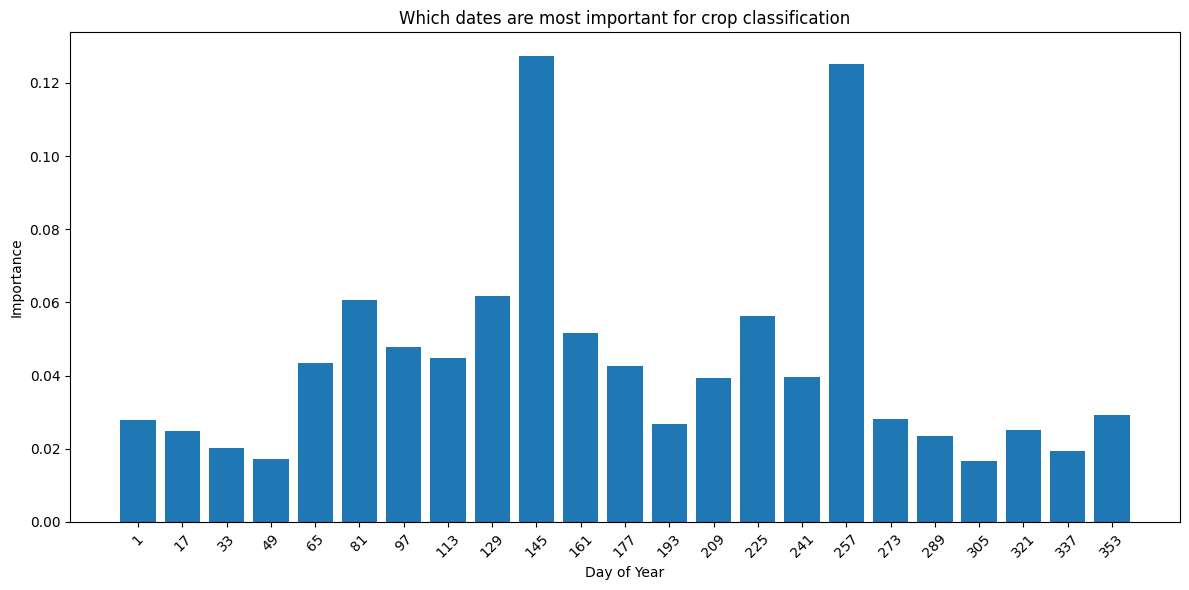

Top 5 most important days of year: [225, 81, 129, 257, 145]


In [7]:
feature_importance = model.feature_importances_
dates = [int(col) for col in X.columns]

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance)
plt.xticks(range(len(feature_importance)), dates, rotation=45)
plt.xlabel('Day of Year')
plt.ylabel('Importance')
plt.title('Which dates are most important for crop classification')
plt.tight_layout()
plt.show()

top_idx = np.argsort(feature_importance)[-5:]
print("Top 5 most important days of year:", [dates[i] for i in top_idx])

In [8]:
test_data = ts.head(20).copy()
test_data.to_csv("test_ndvi_samples.csv", index=False)
print("✅ test_ndvi_samples.csv created with 20 real samples")

✅ test_ndvi_samples.csv created with 20 real samples
